<a href="https://colab.research.google.com/github/Katerinachristopoulou/Data_mining/blob/main/decision_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-4030169382.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Precip Type'].fillna('none', inplace=True)


Excel file created: DecisionTree_Comparison.xlsx


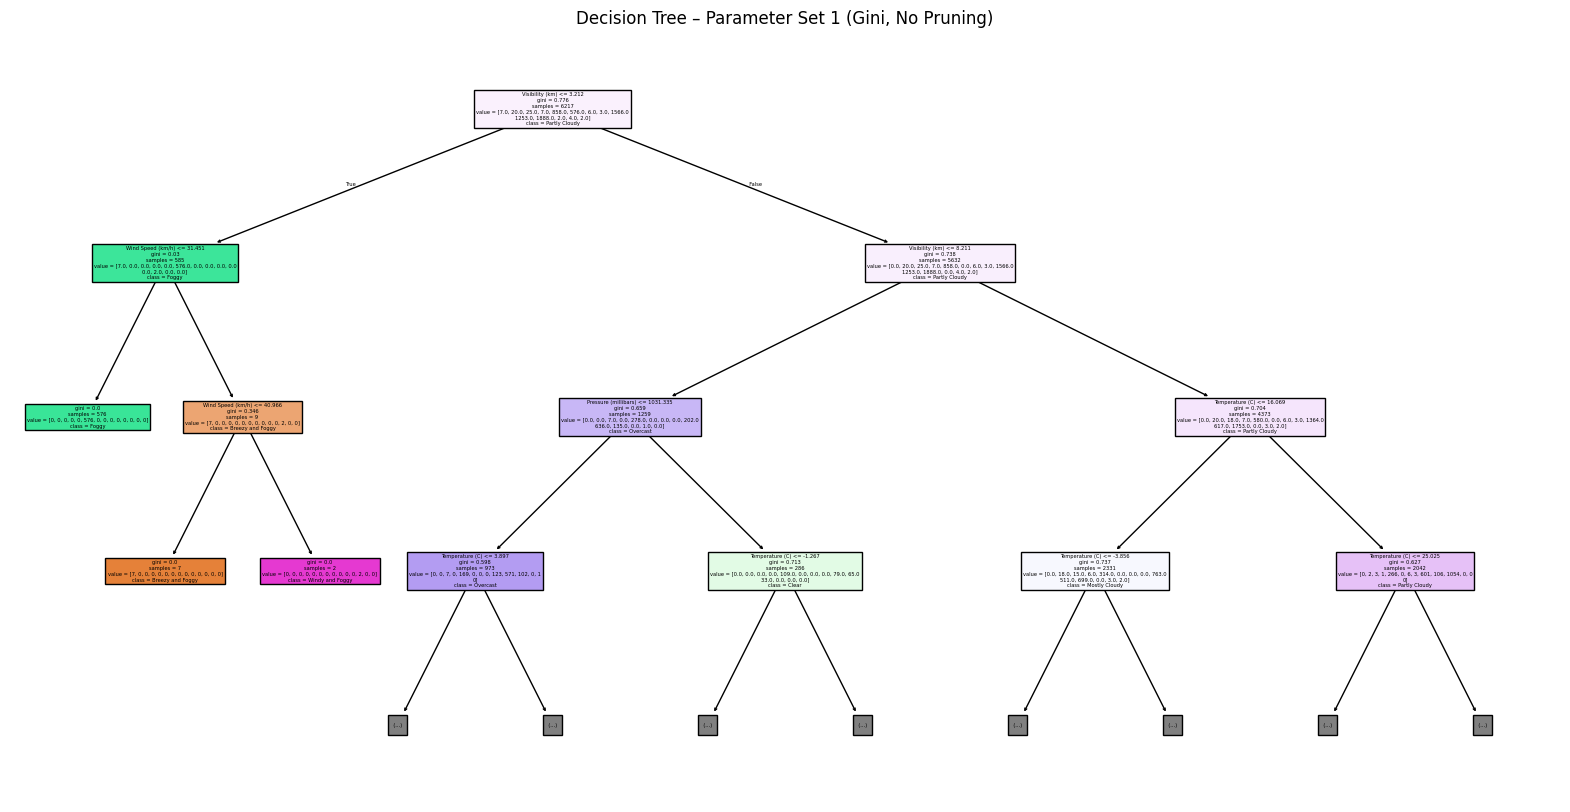

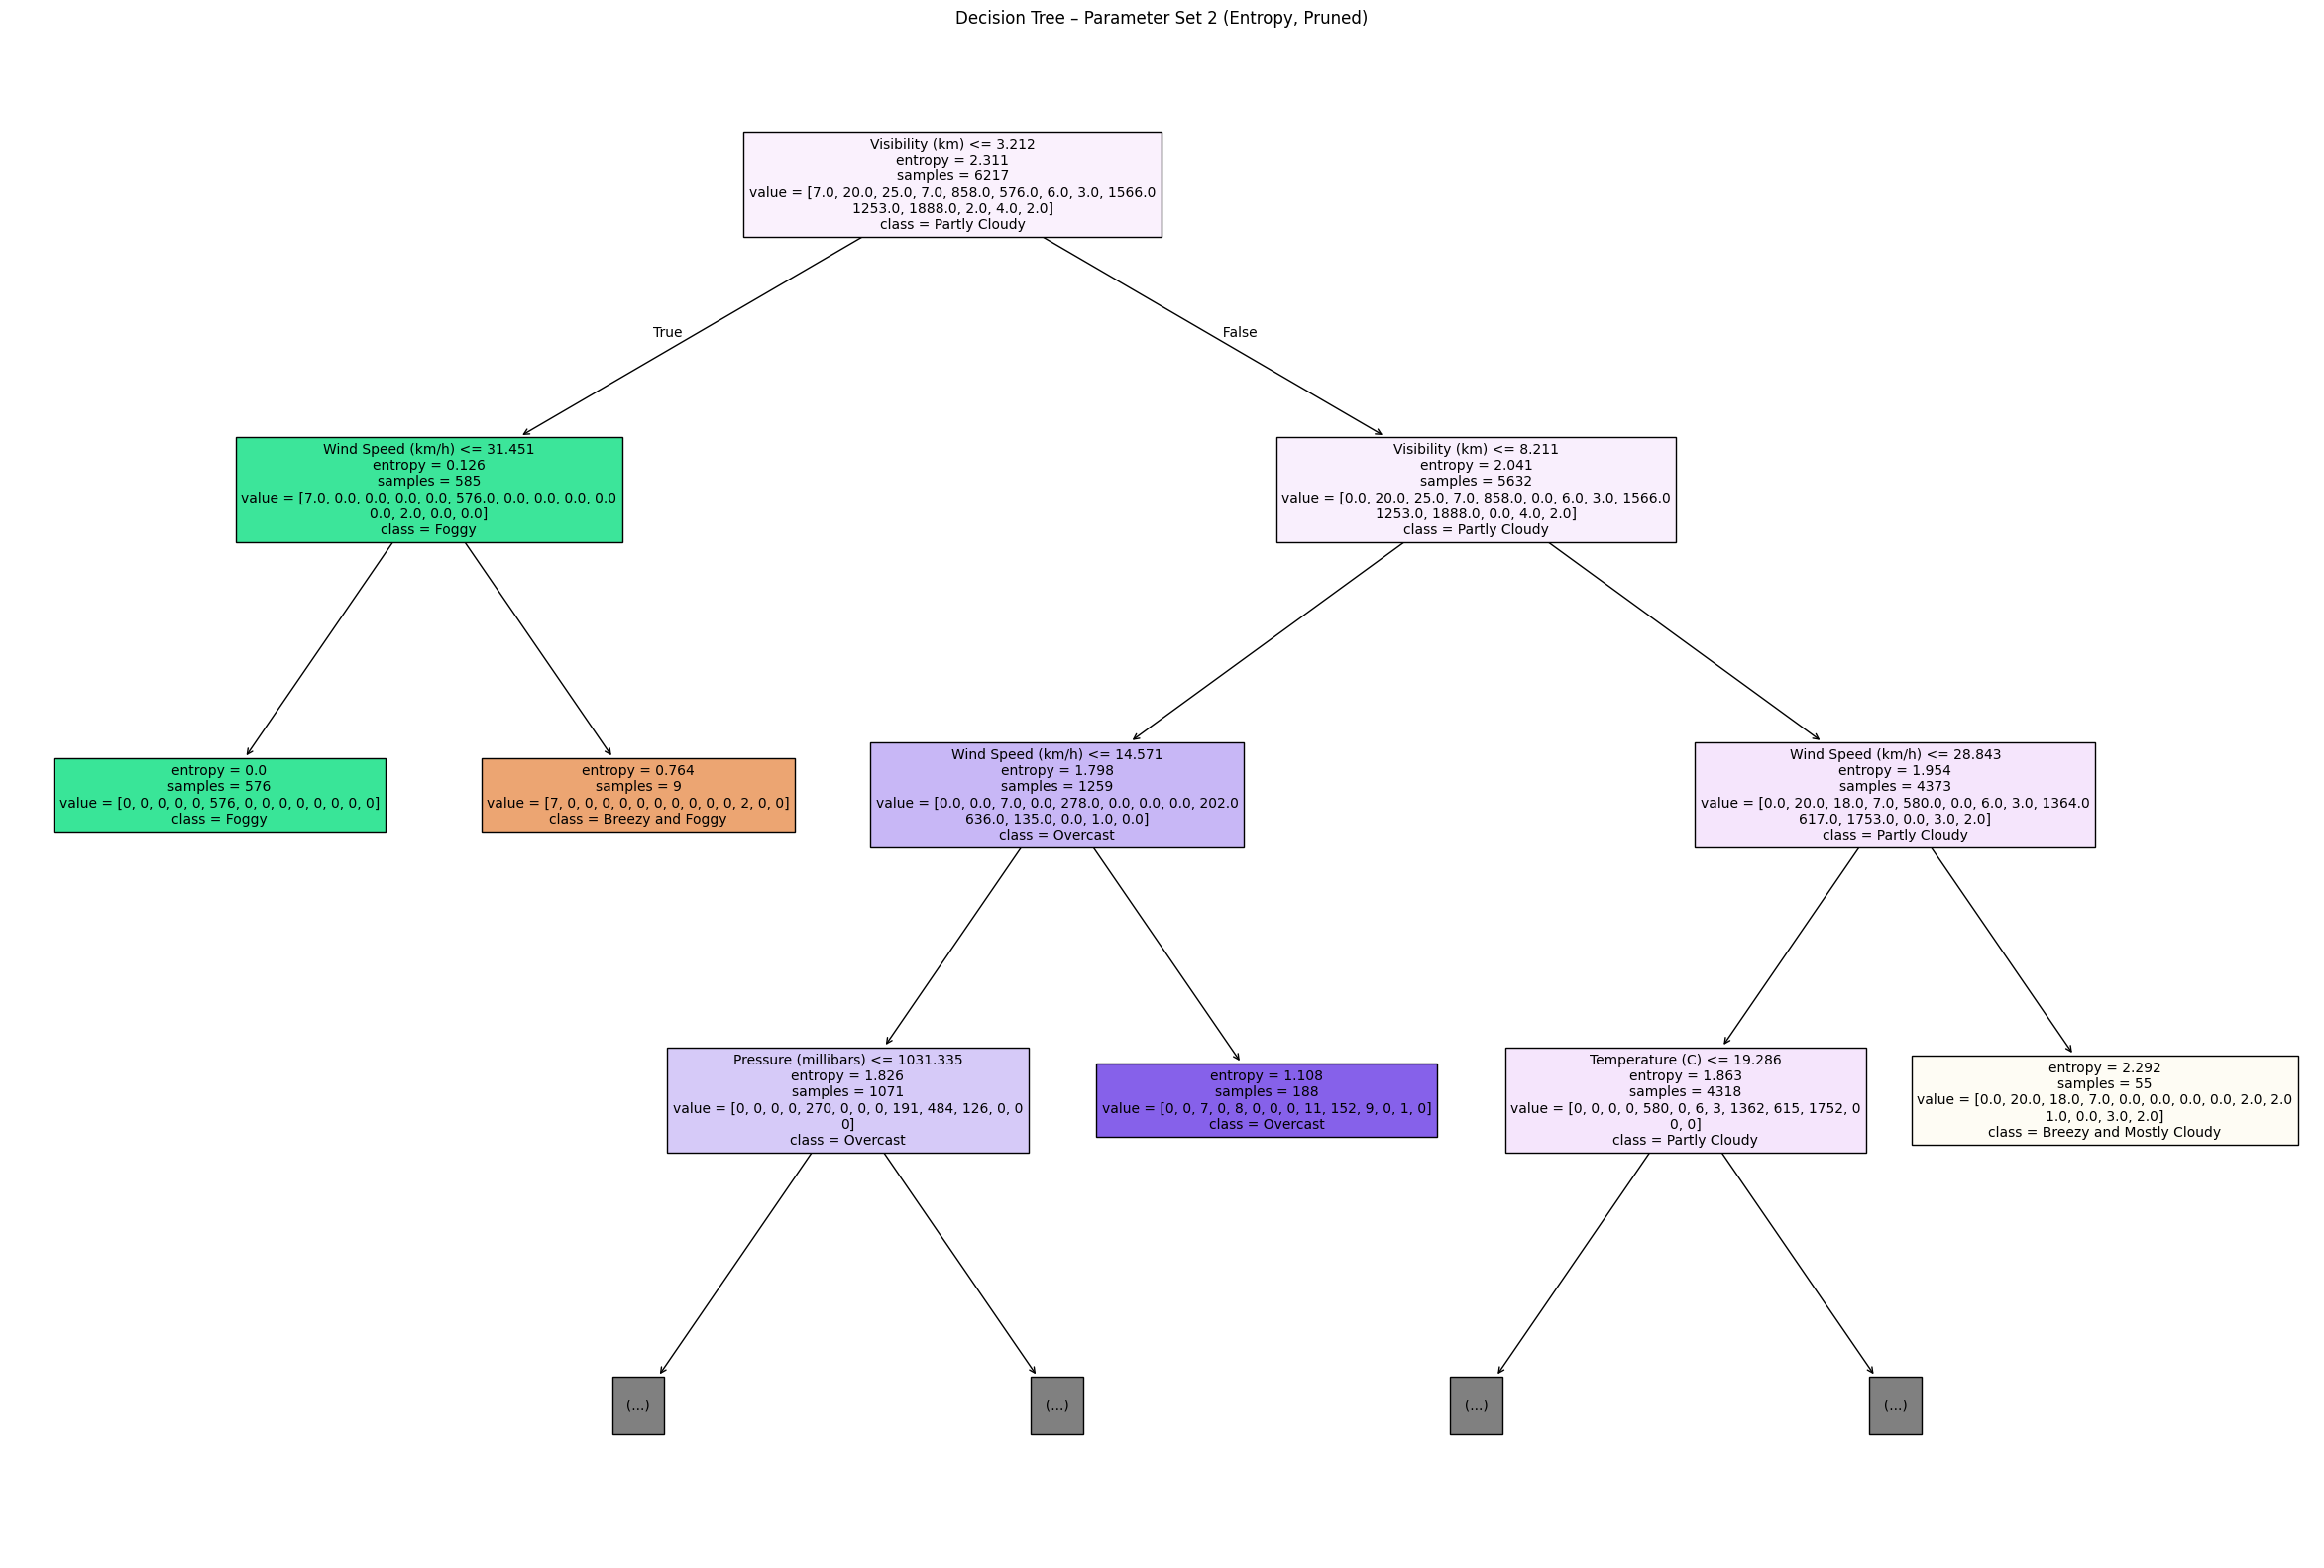

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score
import openpyxl

# ======================================
# LOAD DATASET
# ======================================
df = pd.read_csv("/content/weatherHistory.csv")

# Remove unwanted / leakage-prone columns
df = df.drop(columns=[
    "Formatted Date",
    "Daily Summary",
    "Wind Bearing (degrees)",
    "Apparent Temperature (C)"
])

# Remove rows without target
df = df.dropna(subset=["Summary"])

# Define target and features
y = df["Summary"]
X = df.drop(columns=["Summary"])

# Convert categorical variables
X = pd.get_dummies(X, drop_first=True)
#remove missing values from precip type
df['Precip Type'].fillna('none', inplace=True)
# ======================================
# PARAMETER SETS
# ======================================
param_set_1 = {
    "criterion": "gini",
    "min_samples_leaf": 1,
    "ccp_alpha": 0.0 # Parameter Set 1 for 'Gini, No Pruning'
}

param_set_2 = {
    "criterion": "entropy",
    "min_samples_leaf": 5, # Example pruning
    "ccp_alpha": 0.01 # Parameter Set 2 for 'Entropy, Pruned'
}

# ======================================
# FUNCTION TO BUILD TREE
# ======================================
def build_tree(param_set):
    return DecisionTreeClassifier(**param_set, random_state=42)

results = []

# ======================================
# K-FOLD CROSS VALIDATION
# ======================================
for k in [5, 10]:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    for name, param in [("Set1", param_set_1), ("Set2", param_set_2)]:

        fold_accuracies = []

        for train_index, test_index in kf.split(X):
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = y.iloc[train_index], y.iloc[test_index]

            model = build_tree(param)
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            fold_accuracies.append(acc)

        results.append({
            "Validation Method": "K-Fold",
            "Parameter Set": name,
            "Criterion": param["criterion"],
            "k value / split %": k,
            "Accuracy": np.mean(fold_accuracies),
            "Std Dev": np.std(fold_accuracies)
        })

# ======================================
# TRAIN / TEST SPLITS (Repeated)
# ======================================
num_train_test_runs = 10

for split_size, label in [(0.3, "70/30"), (0.2, "80/20")]:

    for name, param in [("Set1", param_set_1), ("Set2", param_set_2)]:
        accuracies = []

        for _ in range(num_train_test_runs):
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=split_size
            )

            model = build_tree(param)
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            accuracies.append(accuracy_score(y_test, y_pred))

        results.append({
            "Validation Method": "Train/Test",
            "Parameter Set": name,
            "Criterion": param["criterion"],
            "k value / split %": label,
            "Accuracy": np.mean(accuracies),
            "Std Dev": np.std(accuracies)
        })

# ======================================
# EXPORT TO EXCEL
# ======================================
results_df = pd.DataFrame(results)
results_df.to_excel("DecisionTree_Comparison.xlsx", index=False)

print("Excel file created: DecisionTree_Comparison.xlsx")
from sklearn.tree import export_text
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# --------------------------------------
# TRAIN BOTH TREES ON FULL DATASET
# (for visualization purposes only)
# --------------------------------------
tree_set1 = build_tree(param_set_1)
tree_set1.fit(X, y)

tree_set2 = build_tree(param_set_2)
tree_set2.fit(X, y)

# --------------------------------------
# VISUALIZE TREE FROM PARAMETER SET 1
# --------------------------------------
plt.figure(figsize=(20, 10))
plot_tree(
    tree_set1,
    feature_names=X.columns,
    class_names=tree_set1.classes_,
    filled=True,
    max_depth=3  # limit depth for readability
)
plt.title("Decision Tree – Parameter Set 1 (Gini, No Pruning)")
plt.show()

# --------------------------------------
# VISUALIZE TREE FROM PARAMETER SET 2
# --------------------------------------
plt.figure(figsize=(30, 20))
plot_tree(
    tree_set2,
    feature_names=X.columns,
    class_names=tree_set2.classes_,
    filled=True,
    max_depth=3  # same depth for fair comparison
)
plt.title("Decision Tree – Parameter Set 2 (Entropy, Pruned)")
plt.show()

In [ ]:
display(results_df)

,Validation Method,Parameter Set,Criterion,k value / split %,Accuracy,Std Dev
0,K-Fold,Set1,gini,5,0.558629,0.022199
1,K-Fold,Set2,entropy,5,0.508286,0.008028
2,K-Fold,Set1,gini,10,0.569729,0.008463
3,K-Fold,Set2,entropy,10,0.505708,0.018727
4,Train/Test,Set1,gini,70/30,0.554019,0.012152
5,Train/Test,Set2,entropy,70/30,0.507503,0.013059
6,Train/Test,Set1,gini,80/20,0.567685,0.014747
7,Train/Test,Set2,entropy,80/20,0.506431,0.014085


In [ ]:
# --------------------------------------
# GENERALIZE SUMMARY CLASSES
# --------------------------------------
def simplify_summary(x):
    x = str(x).lower()
    if "rain" in x or "drizzle" in x:
        return "Rain"
    elif "snow" in x:
        return "Snow"
    elif "clear" in x:
        return "Clear"
    else:
        return "Cloudy"


df["Summary_Simple"] = df["Summary"].apply(simplify_summary)

# Redefine target and features
y = df["Summary_Simple"]
X = df.drop(columns=["Summary", "Summary_Simple"])


# Convert categorical variables
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# --------------------------------------
# CONTROLLED DECISION TREE
# --------------------------------------
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    min_samples_leaf=15,
    ccp_alpha=1e-4,
    class_weight="balanced",
    random_state=42
)

# --------------------------------------
# 5-FOLD CROSS-VALIDATION
# --------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, preds))

print("Generalized Decision Tree Accuracy:", np.mean(accuracies))
print("Std deviation:", np.std(accuracies))

Generalized Decision Tree Accuracy: 0.7435987510767694
Std deviation: 0.023182338981760434


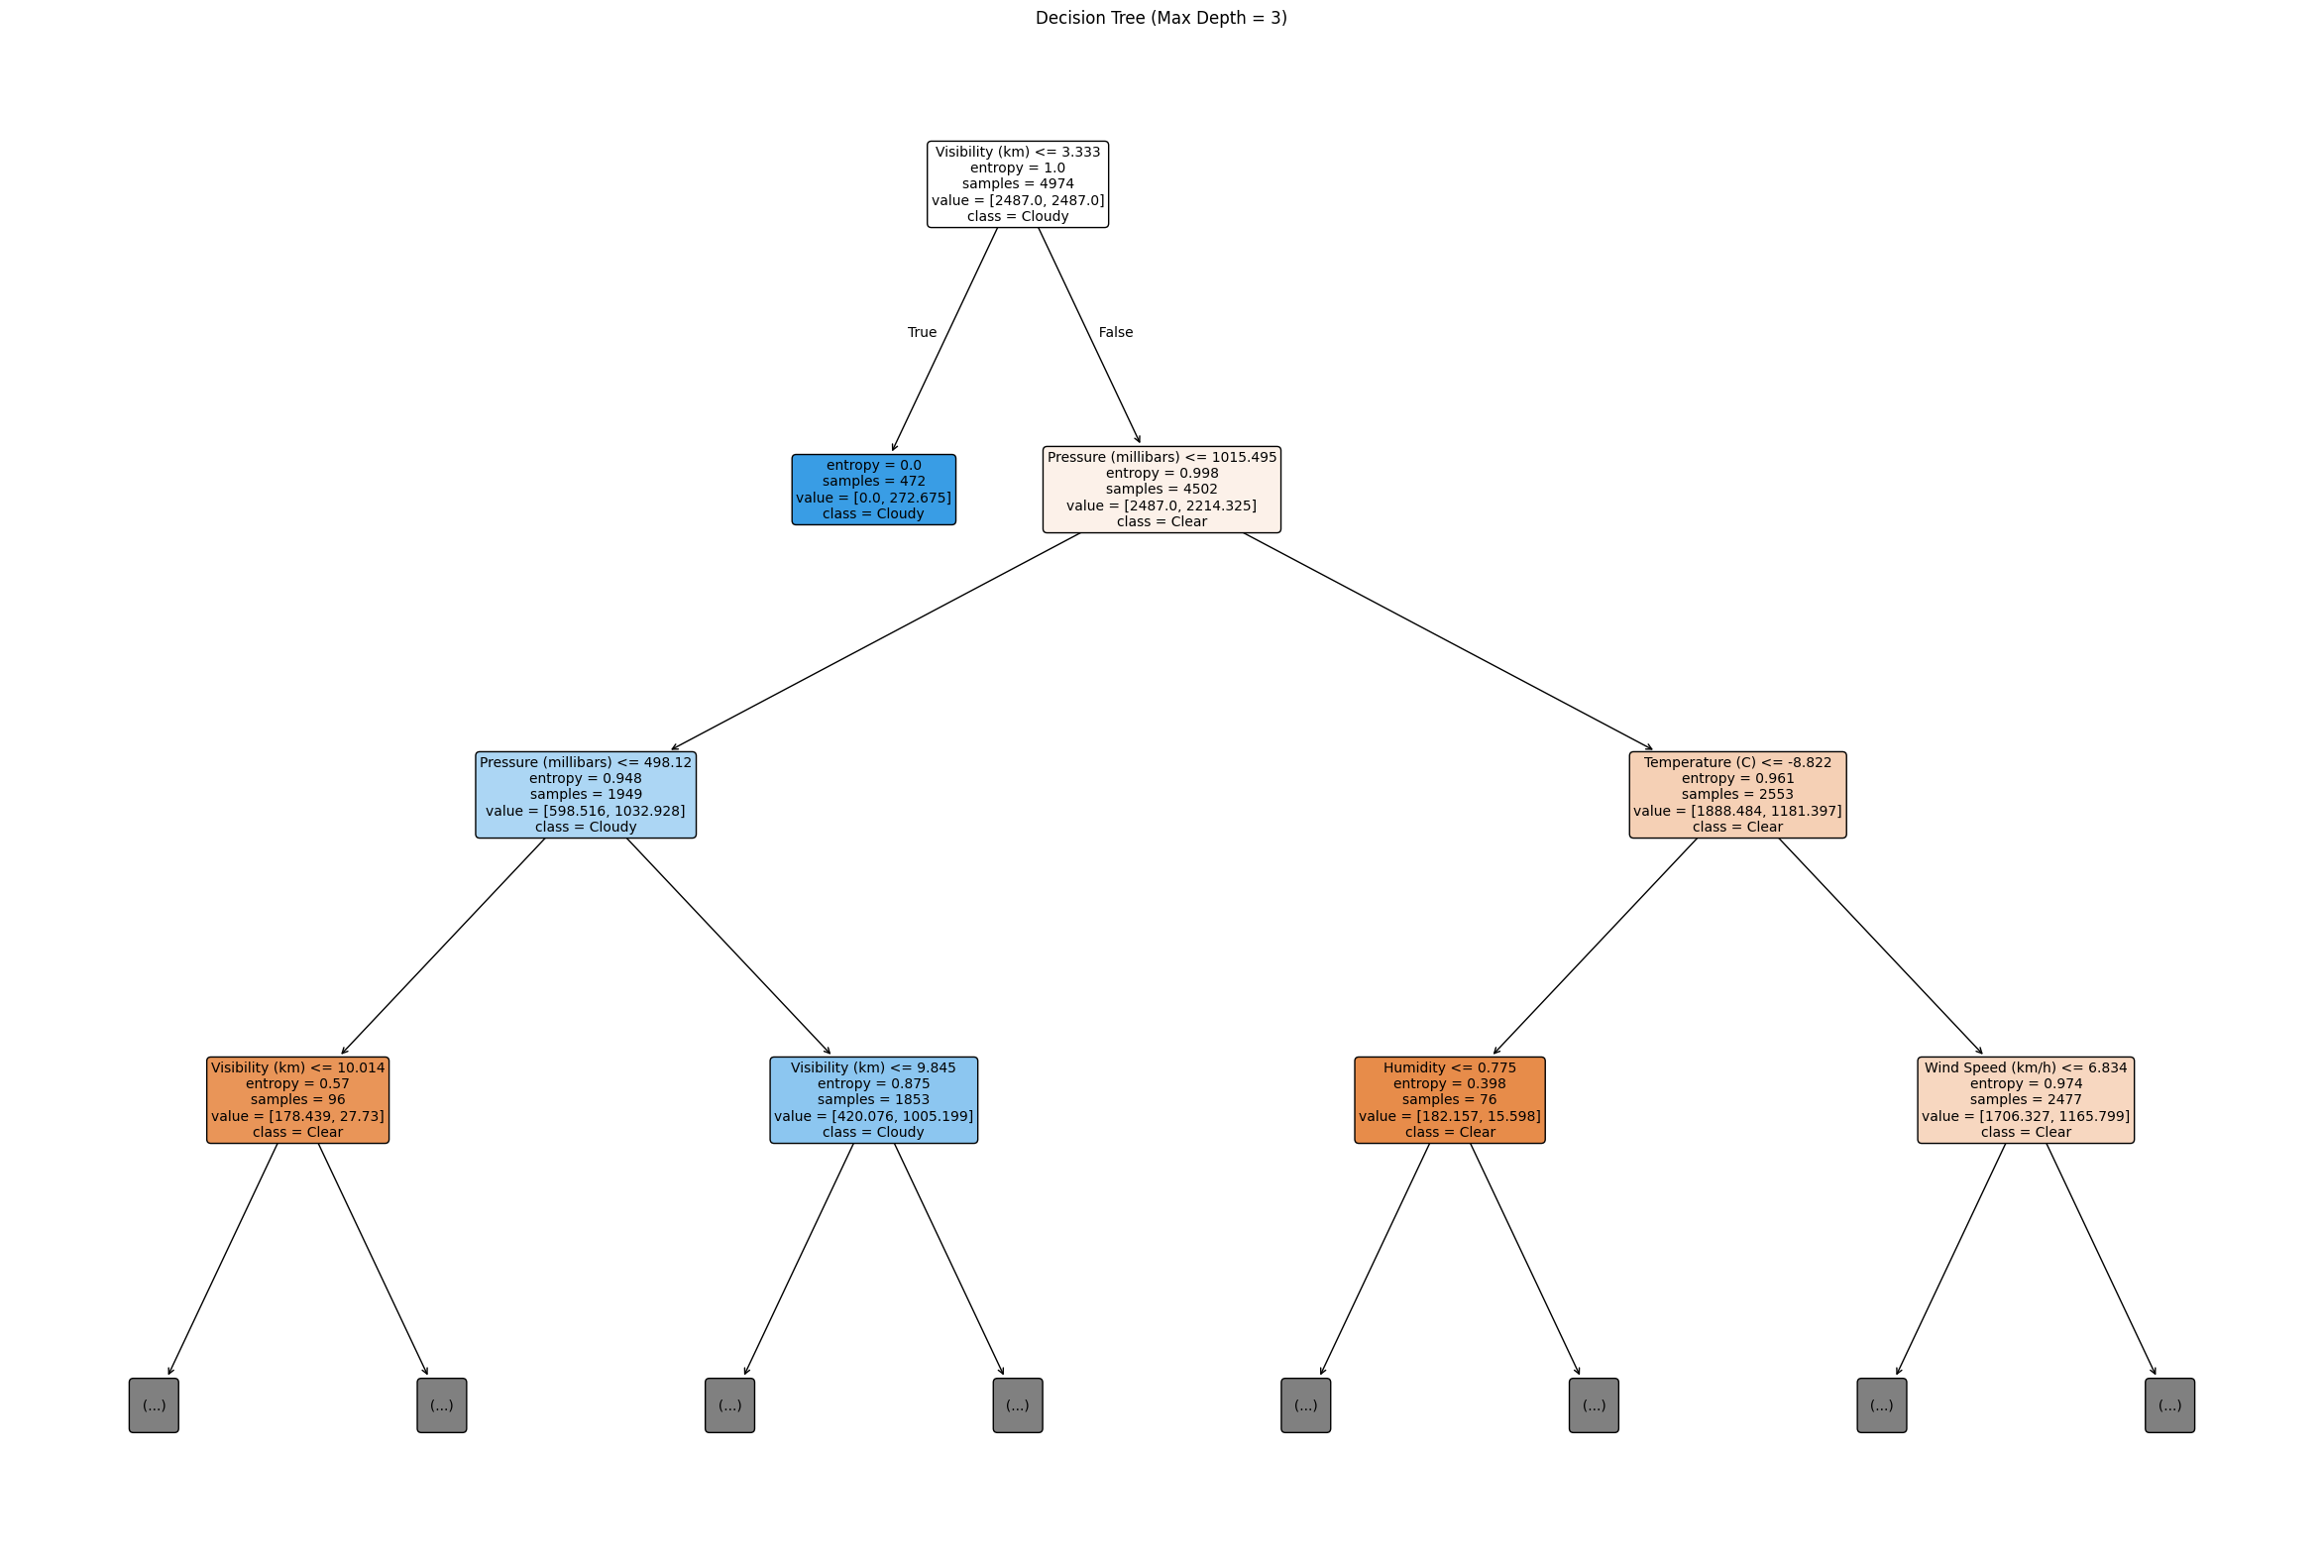

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Prepare feature names and class names for visualization
feature_names = X.columns.tolist()
class_names = [str(c) for c in model.classes_]

# --- Visualization with max_depth=3 ---
plt.figure(figsize=(30, 20))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.title("Decision Tree (Max Depth = 3)")
plt.show()

In [ ]:
from sklearn.tree import export_text
from sklearn.model_selection import KFold

# --------------------------------------
# CHOOSE FINAL MODEL (entropy recommended)
# --------------------------------------
final_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    min_samples_leaf=15,
    ccp_alpha=1e-4,
    class_weight="balanced",
    random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

split_rows = []

# --------------------------------------
# EXTRACT SPLITS PER FOLD
# --------------------------------------
for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]

    final_model.fit(X_train, y_train)

    tree_text = export_text(
        final_model,
        feature_names=list(X.columns)
    )

    for line in tree_text.split("\n"):
        if "|---" in line:
            depth = line.count("|   ")
            rule = line.replace("|", "").strip()

            split_rows.append({
                "Fold": fold,
                "Depth Level": depth,
                "Split Rule": rule
            })

# --------------------------------------
# EXPORT SPLITS TO EXCEL
# --------------------------------------
splits_df = pd.DataFrame(split_rows)
splits_df.to_excel("DecisionTree_Split_Visualization.xlsx", index=False)

print("Excel file created: DecisionTree_Split_Visualization.xlsx")

Excel file created: DecisionTree_Split_Visualization.xlsx


In [ ]:
import pandas as pd
from sklearn.model_selection import KFold

# Load data
data = pd.read_csv('/content/weatherHistory.csv')
data = data.dropna(subset=['Precip Type'])
data = data.reset_index(drop=True)

n_samples = len(data)

def create_kfold_grid(n_samples, k):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    grid = pd.DataFrame(index=range(n_samples))

    for fold, (train_idx, test_idx) in enumerate(kf.split(range(n_samples)), start=1):
        col_name = f"K{k}_Fold{fold}"
        grid[col_name] = "TRAIN"
        grid.loc[test_idx, col_name] = "TEST"

    return grid

# Create grids
k5_grid = create_kfold_grid(n_samples, 5)
k10_grid = create_kfold_grid(n_samples, 10)

In [ ]:
from sklearn.model_selection import train_test_split

def create_train_test_grid(n_samples, test_size, runs=5):
    grid = pd.DataFrame(index=range(n_samples))

    for run in range(1, runs + 1):
        _, X_test = train_test_split(
            range(n_samples),
            test_size=test_size,
            random_state=run,
            shuffle=True
        )

        col_name = f"{int((1-test_size)*100)}/{int(test_size*100)}_Run{run}"
        grid[col_name] = "TRAIN"
        grid.loc[X_test, col_name] = "TEST"

    return grid

# Create grids
tt_70_30_grid = create_train_test_grid(n_samples, 0.3)
tt_80_20_grid = create_train_test_grid(n_samples, 0.2)

In [ ]:
calculations_grid = pd.concat(
    [k5_grid, k10_grid, tt_70_30_grid, tt_80_20_grid],
    axis=1
)

calculations_grid.head()

,K5_Fold1,K5_Fold2,K5_Fold3,K5_Fold4,K5_Fold5,K10_Fold1,K10_Fold2,K10_Fold3,K10_Fold4,K10_Fold5,...,70/30_Run1,70/30_Run2,70/30_Run3,70/30_Run4,70/30_Run5,80/20_Run1,80/20_Run2,80/20_Run3,80/20_Run4,80/20_Run5
0,TRAIN,TRAIN,TEST,TRAIN,TRAIN,TRAIN,TRAIN,TRAIN,TRAIN,TEST,...,TRAIN,TRAIN,TEST,TRAIN,TEST,TRAIN,TRAIN,TEST,TRAIN,TEST
1,TRAIN,TRAIN,TRAIN,TEST,TRAIN,TRAIN,TRAIN,TRAIN,TRAIN,TRAIN,...,TRAIN,TRAIN,TRAIN,TEST,TEST,TRAIN,TRAIN,TRAIN,TEST,TEST
2,TRAIN,TRAIN,TRAIN,TEST,TRAIN,TRAIN,TRAIN,TRAIN,TRAIN,TRAIN,...,TRAIN,TRAIN,TRAIN,TEST,TRAIN,TRAIN,TRAIN,TRAIN,TRAIN,TRAIN
3,TRAIN,TRAIN,TRAIN,TRAIN,TEST,TRAIN,TRAIN,TRAIN,TRAIN,TRAIN,...,TEST,TEST,TRAIN,TRAIN,TRAIN,TRAIN,TEST,TRAIN,TRAIN,TRAIN
4,TRAIN,TRAIN,TRAIN,TRAIN,TEST,TRAIN,TRAIN,TRAIN,TRAIN,TRAIN,...,TEST,TEST,TRAIN,TRAIN,TRAIN,TEST,TRAIN,TRAIN,TRAIN,TRAIN


In [ ]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.8 MB/s eta 0:00:00


In [ ]:
with pd.ExcelWriter("split_calculations_grid.xlsx", engine="xlsxwriter") as writer:
    k5_grid.to_excel(writer, sheet_name="K5_Splits")
    k10_grid.to_excel(writer, sheet_name="K10_Splits")
    tt_70_30_grid.to_excel(writer, sheet_name="70_30_Splits")
    tt_80_20_grid.to_excel(writer, sheet_name="80_20_Splits")
    calculations_grid.to_excel(writer, sheet_name="ALL_SPLITS")

print("Excel file created: split_calculations_grid.xlsx")

Excel file created: split_calculations_grid.xlsx
